# Exercise 3: Pixelwise operations

In [5]:
from skimage import color, io, measure, img_as_ubyte
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom

## Exercise 1

In [6]:
# Directory containing data and images
in_dir = "data/"

# X-ray image
im_name = "vertebra.png"

# Read the image
im_org = io.imread(in_dir + im_name)

In [7]:
print(im_org.shape)
print(im_org.dtype)

(998, 800)
uint8


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3181175008.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3181175008.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


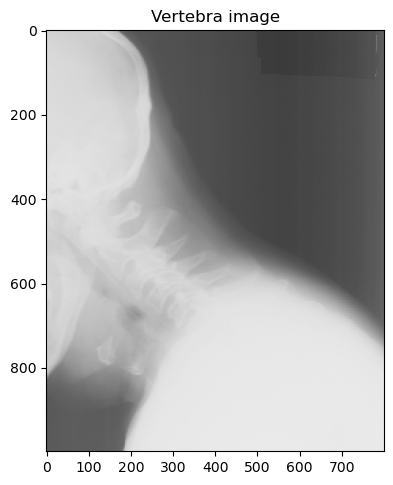

In [8]:
io.imshow(im_org)
plt.title('Vertebra image')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2584199610.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


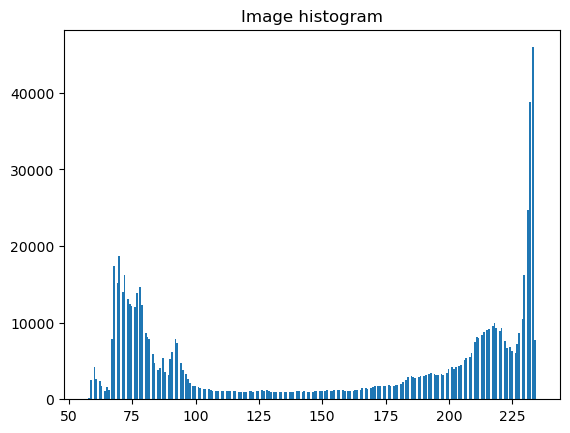

In [9]:
plt.hist(im_org.ravel(), bins=256)
plt.title('Image histogram')
io.show()

It is a bimodal image but it will be hard to segment it so only the bones are visible since there are many pixels with middle values, as it can be seen in the histogram between the two peaks.

## Exercise 2

In [10]:
print("Minimum pixel value:", np.min(im_org))
print("Maximum pixel value:", np.max(im_org))

Minimum pixel value: 57
Maximum pixel value: 235


The image does NOT use the full scale of the gray-scale spectrum, so we could enhance the appearance of the image.

## Exercise 3

In [11]:
from skimage.util import img_as_float
from skimage.util import img_as_ubyte

In [12]:
float_image = img_as_float(im_org)
print(float_image.dtype)
print("Minimum pixel value:", np.min(float_image))
print("Maximum pixel value:", np.max(float_image))

float64
Minimum pixel value: 0.22352941176470587
Maximum pixel value: 0.9215686274509803


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2571228252.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(float_image)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2571228252.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


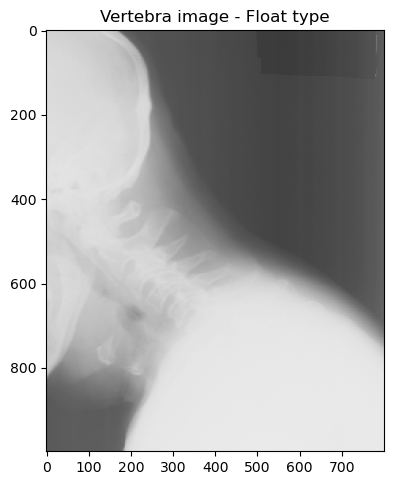

In [13]:
io.imshow(float_image)
plt.title('Vertebra image - Float type')
io.show()

In [14]:
# Verify that the float image is equal to the original image, where each pixel value is divided by 255
print(np.min(im_org / 255.0))
print(np.max(im_org / 255.0))

0.2235294117647059
0.9215686274509803


## Exercise 4

In [15]:
ubyte_image = img_as_ubyte(float_image)
print(ubyte_image.dtype)
print("Minimum pixel value:", np.min(ubyte_image))
print("Maximum pixel value:", np.max(ubyte_image))

uint8
Minimum pixel value: 57
Maximum pixel value: 235


In [16]:
# Verify that the float image is equal to the float converted image, where each pixel value is multiplied by 255
print(np.min(float_image * 255.0))
print(np.max(float_image * 255.0))

56.99999999999999
235.0


(!) Remember that all decimal number will be converted into integers by this, and some information might be lost.

## Exercise 5

In [17]:
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image 
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0
	
    # Do something here
    img_out = ((max_desired - min_desired) / (max_val - min_val)) * (img_float - min_val) + min_desired

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)

In [18]:
stretched_img = histogram_stretch(im_org)
print('Min value after stretching the image:', np.min(stretched_img))
print('Max value after stretching the image:', np.max(stretched_img))

Min value after stretching the image: 0
Max value after stretching the image: 255


## Exercise 6

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2549865246.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2549865246.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(stretched_img, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2549865246.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


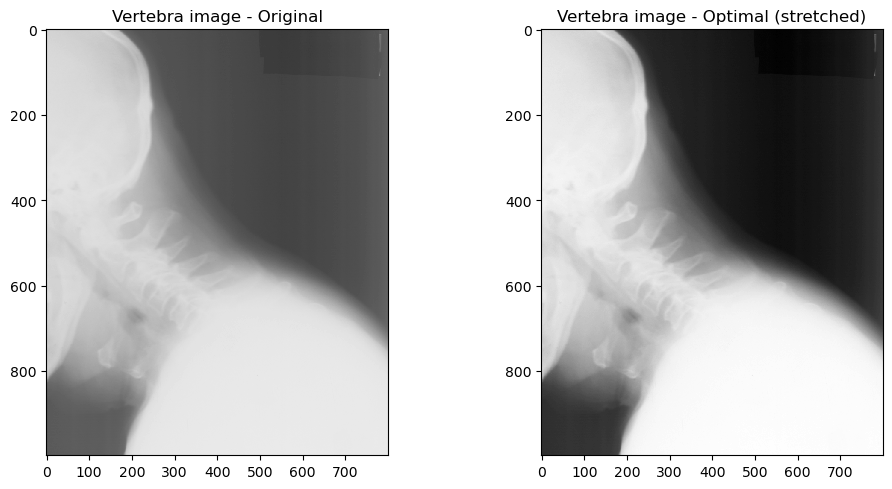

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org, ax=ax[0])
ax[0].set_title('Vertebra image - Original')
io.imshow(stretched_img, ax=ax[1])
ax[1].set_title('Vertebra image - Optimal (stretched)')
fig.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1667742597.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


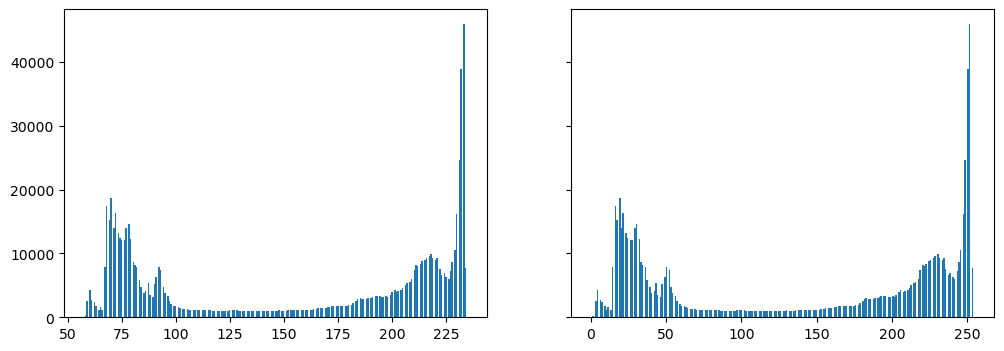

In [20]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 4))

ax[0].hist(im_org.ravel(), bins=256)
ax[1].hist(stretched_img.ravel(), bins=256)

fig.show()

## Exercise 7

In [21]:
def gamma_map(img_in, gamma):
    """
    Applies gamma correction to an image
    :param img_in: Input image
    :param gamma: Gamma value
    :return: Image with gamma correction applied
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
	
    # Do something here
    img_out = np.power(img_float, gamma)

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)


## Exercise 8

In [22]:
img_gamma_05 = gamma_map(im_org, 0.5)
print('Min value after 0.5 gamma correction:', np.min(img_gamma_05))
print('Max value after 0.5 gamma correction:', np.max(img_gamma_05))

Min value after 0.5 gamma correction: 121
Max value after 0.5 gamma correction: 245


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2318218557.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2318218557.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gamma_05, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2318218557.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


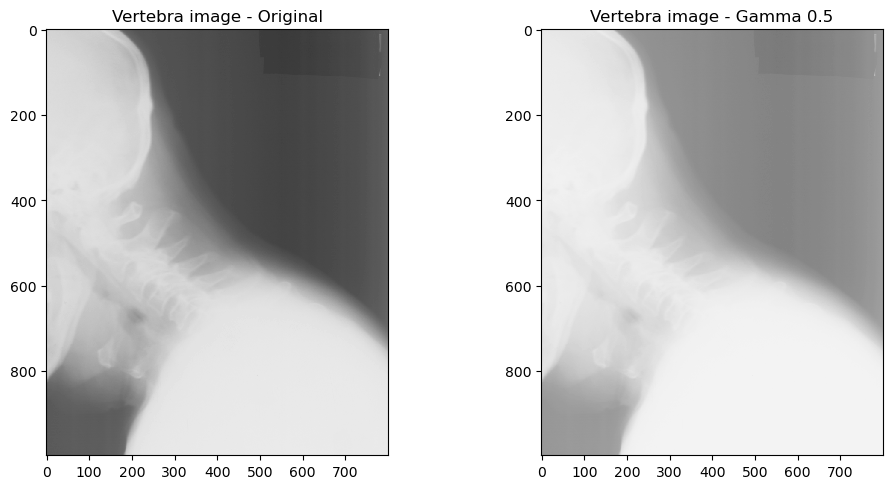

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org, ax=ax[0])
ax[0].set_title('Vertebra image - Original')
io.imshow(img_gamma_05, ax=ax[1])
ax[1].set_title('Vertebra image - Gamma 0.5')
fig.show()

In [24]:
img_gamma_20 = gamma_map(im_org, 2.0)
print('Min value after 2.0 gamma correction:', np.min(img_gamma_20))
print('Max value after 2.0 gamma correction:', np.max(img_gamma_20))

Min value after 2.0 gamma correction: 13
Max value after 2.0 gamma correction: 217


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2666270021.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2666270021.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gamma_20, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2666270021.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


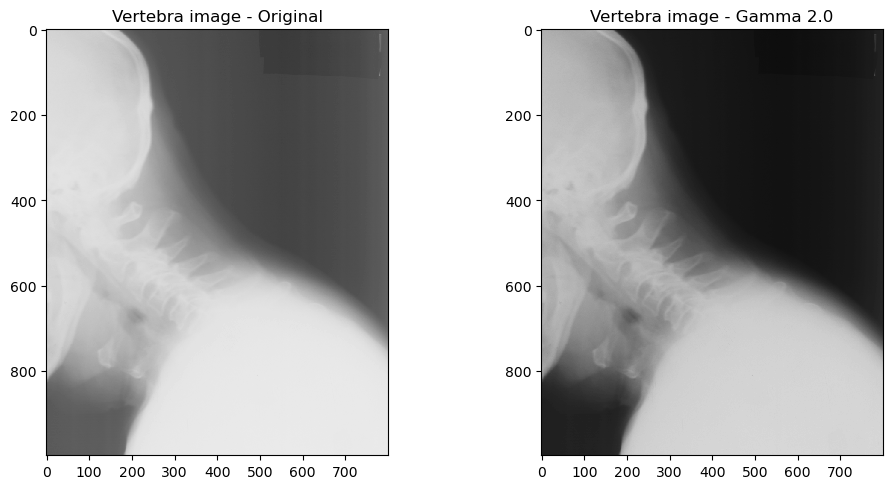

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org, ax=ax[0])
ax[0].set_title('Vertebra image - Original')
io.imshow(img_gamma_20, ax=ax[1])
ax[1].set_title('Vertebra image - Gamma 2.0')
fig.show()

In [26]:
img_gamma_50 = gamma_map(im_org, 5.0)
print('Min value after 5.0 gamma correction:', np.min(img_gamma_50))
print('Max value after 5.0 gamma correction:', np.max(img_gamma_50))

Min value after 5.0 gamma correction: 0
Max value after 5.0 gamma correction: 170


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/854898981.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/854898981.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_gamma_50, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/854898981.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


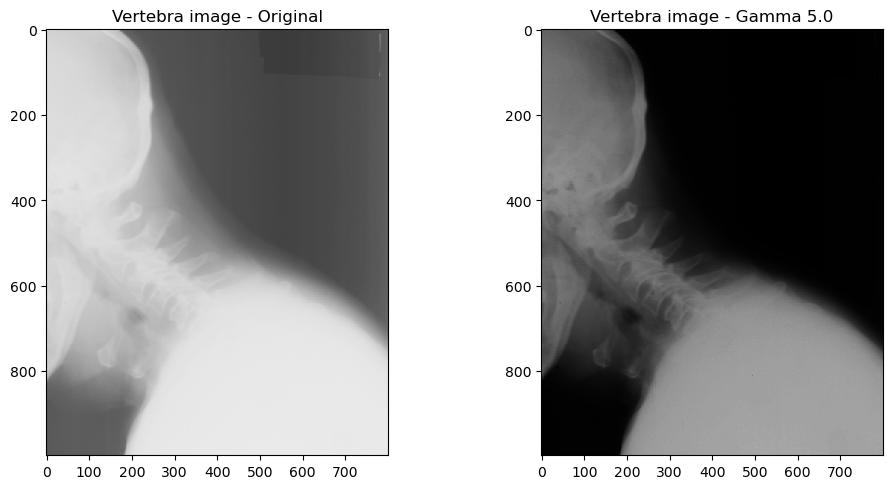

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org, ax=ax[0])
ax[0].set_title('Vertebra image - Original')
io.imshow(img_gamma_50, ax=ax[1])
ax[1].set_title('Vertebra image - Gamma 5.0')
fig.show()

## Exercise 9

In [28]:
def threshold_image(img_in, thres):
    """
    Apply a threshold in an image and return the resulting image
    :param img_in: Input image
    :param thres: The treshold value in the range [0, 255]
    :return: Resulting image (unsigned byte) where background is 0 and foreground is 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)

    if (thres > 255):
        print("Threshold value should be in the range [0, 255]")
        return None
	
    # Do something here
    foreground = img_float >= (thres / 255)
    background = img_float < (thres / 255)
    
    img_out = np.zeros_like(img_float)
    img_out[foreground] = 1.0
    img_out[background] = 0.0

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)


## Exercise 10

In [29]:
img_threshold_100 = threshold_image(im_org, 100)
img_threshold_150 = threshold_image(im_org, 150)
img_threshold_200 = threshold_image(im_org, 200)
img_threshold_220 = threshold_image(im_org, 220)


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1590824195.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_100, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1590824195.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_150, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1590824195.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_200, ax=ax[2])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1590824195.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in vers

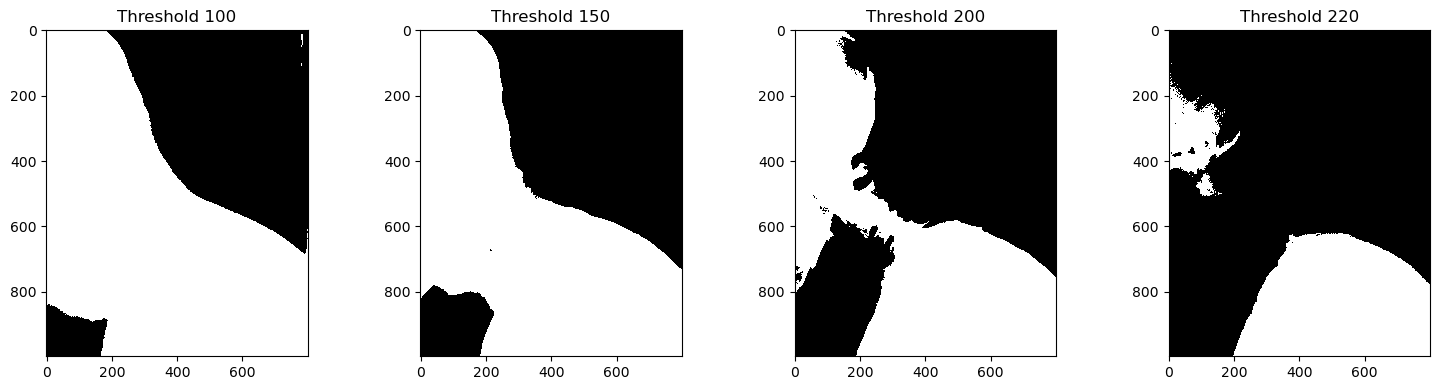

In [30]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
io.imshow(img_threshold_100, ax=ax[0])
ax[0].set_title('Threshold 100')
io.imshow(img_threshold_150, ax=ax[1])
ax[1].set_title('Threshold 150')
io.imshow(img_threshold_200, ax=ax[2])
ax[2].set_title('Threshold 200')
io.imshow(img_threshold_220, ax=ax[3])
ax[3].set_title('Threshold 220')
fig.show()

## Exercise 11

In [31]:
from skimage.filters import threshold_otsu

In [32]:
thres_otsu = threshold_otsu(im_org)
print("Otsu's threshold value:", thres_otsu)

Otsu's threshold value: 148


In [33]:
img_threshold_otsu = threshold_image(im_org, thres_otsu)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1618546472.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1618546472.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_otsu, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/1618546472.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


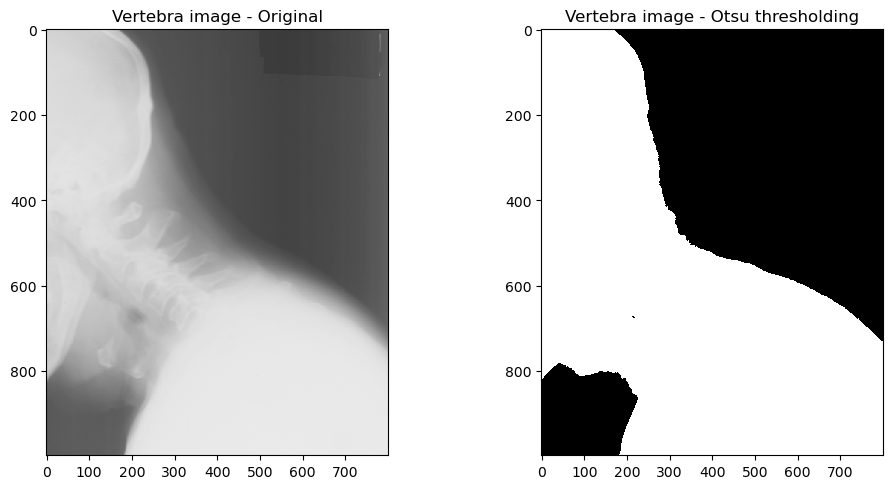

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_org, ax=ax[0])
ax[0].set_title('Vertebra image - Original')
io.imshow(img_threshold_otsu, ax=ax[1])
ax[1].set_title('Vertebra image - Otsu thresholding')
fig.show()

## Exercise 12

In [35]:
# Dark background image
im_name = "dark_background.png"

# Read the image
im_dark = io.imread(in_dir + im_name)

In [36]:
print(im_dark.shape)
print(im_dark.dtype)
print("Minimum pixel value:", np.min(im_dark))
print("Maximum pixel value:", np.max(im_dark))

(510, 776, 3)
uint8
Minimum pixel value: 0
Maximum pixel value: 252


/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/217156795.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dark)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/217156795.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


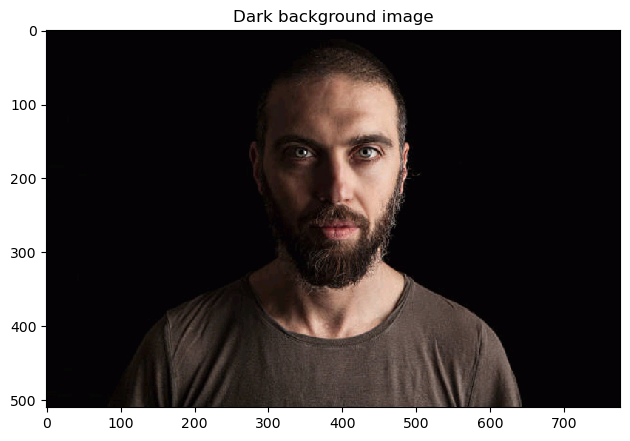

In [37]:
io.imshow(im_dark)
plt.title('Dark background image')
io.show()

In [38]:
im_dark_gray = img_as_ubyte(color.rgb2gray(im_dark))

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/208565620.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dark_gray)
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/208565620.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


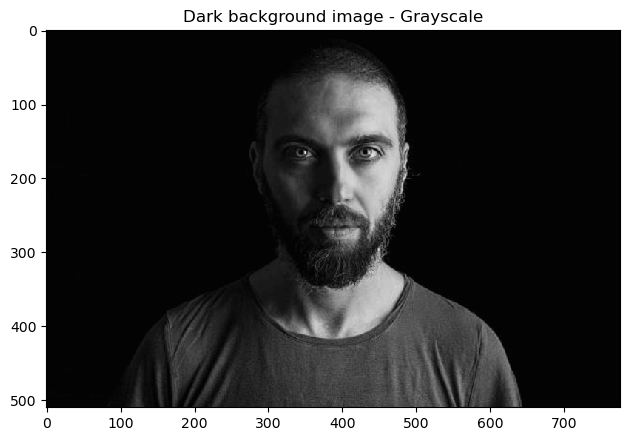

In [39]:
io.imshow(im_dark_gray)
plt.title('Dark background image - Grayscale')
io.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/750672274.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


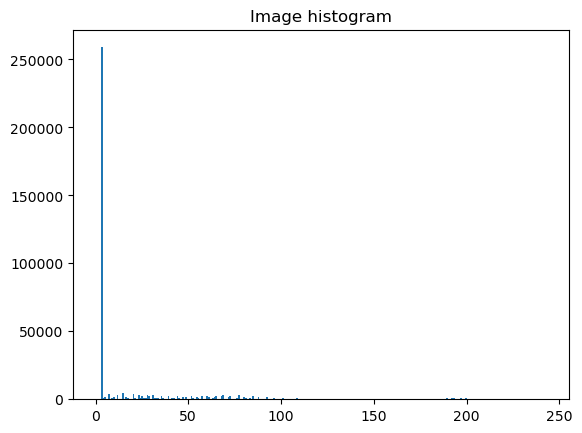

In [40]:
plt.hist(im_dark_gray.ravel(), bins=256)
plt.title('Image histogram')
io.show()

In [41]:
thres_otsu_dark_gray = threshold_otsu(im_dark_gray)
print("Otsu's threshold value:", thres_otsu_dark_gray)

Otsu's threshold value: 58


In [42]:
img_threshold_otsu_silhouette = threshold_image(im_dark_gray, thres_otsu_dark_gray)

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3368536993.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dark_gray, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3368536993.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_otsu_silhouette, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3368536993.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


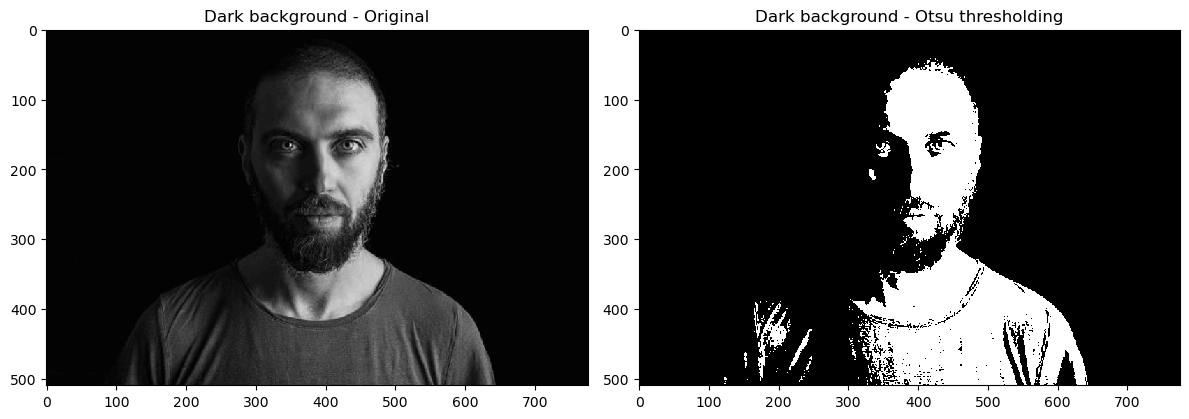

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_dark_gray, ax=ax[0])
ax[0].set_title('Dark background - Original')
io.imshow(img_threshold_otsu_silhouette, ax=ax[1])
ax[1].set_title('Dark background - Otsu thresholding')
fig.show()

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3487308195.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dark_gray, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3487308195.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_threshold_otsu_silhouette, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/3487308195.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


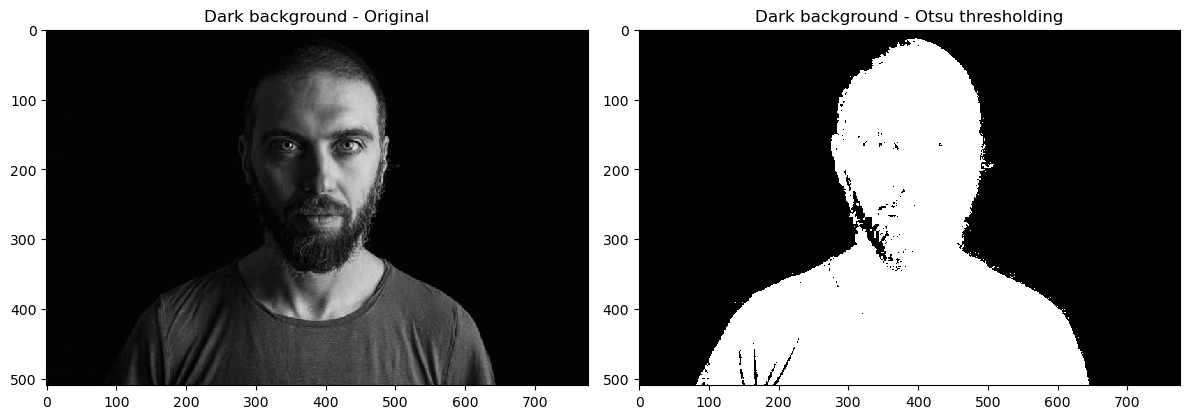

In [44]:
# Manual thresholding
img_threshold_otsu_silhouette = threshold_image(im_dark_gray, 6)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
io.imshow(im_dark_gray, ax=ax[0])
ax[0].set_title('Dark background - Original')
io.imshow(img_threshold_otsu_silhouette, ax=ax[1])
ax[1].set_title('Dark background - Otsu thresholding')
fig.show()


## Exercise 13

In [59]:
def detect_dtu_signs(img_in, color = 'blue'):

    r_comp = img_in[:, :, 0]
    g_comp = img_in[:, :, 1]
    b_comp = img_in[:, :, 2]

    if color == 'blue':
        segm = (r_comp < 10) & (g_comp > 85) & (g_comp < 105) & \
                    (b_comp > 180) & (b_comp < 200)
    elif color == 'red':
        segm = (r_comp > 160) & (r_comp < 180) & \
                   (g_comp < 70) & (b_comp < 70)
    else:
        print("Color not supported. Please choose 'red' or 'blue'.")
        return None

    img_out = img_in.copy()
    img_out[segm] = [255, 255, 255]
    img_out[~segm] = [0, 0, 0]

    return img_out


In [60]:
# DTU Signs image
im_name = "DTUSigns2.jpg"

# Read the image
im_dtu_signs = io.imread(in_dir + im_name)

In [61]:
im_dtu_signs_detected_blue = detect_dtu_signs(im_dtu_signs, color='blue')
im_dtu_signs_detected_red = detect_dtu_signs(im_dtu_signs, color='red')

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/989731531.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/989731531.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs_detected_blue, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/989731531.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs_detected_red, ax=ax[2])
/Users/balpaula/miniforge3/envs/dtu02515/lib/python3.13/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displa

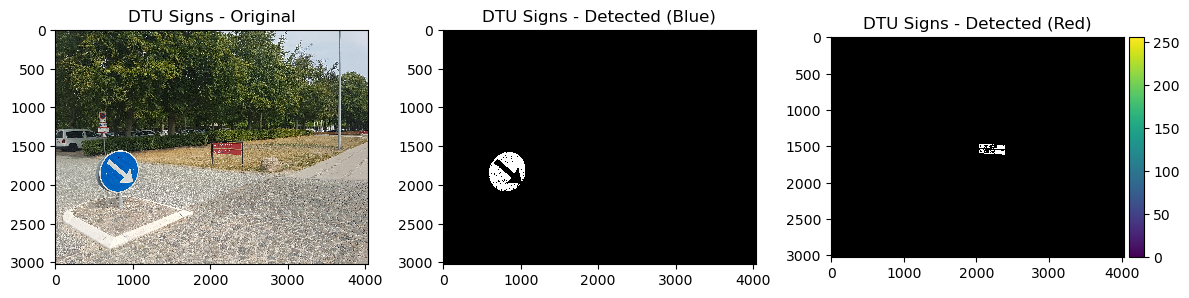

In [62]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
io.imshow(im_dtu_signs, ax=ax[0])
ax[0].set_title('DTU Signs - Original')
io.imshow(im_dtu_signs_detected_blue, ax=ax[1])
ax[1].set_title('DTU Signs - Detected (Blue)')
io.imshow(im_dtu_signs_detected_red, ax=ax[2])
ax[2].set_title('DTU Signs - Detected (Red)')
fig.show()


In [63]:
# %matplotlib qt5
# io.imshow(im_dtu_signs)
# plt.title('DTU Signs - Original')
# io.show()

## Exercise 15

In [64]:
from skimage.color import rgb2hsv

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/2227746794.py:16: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


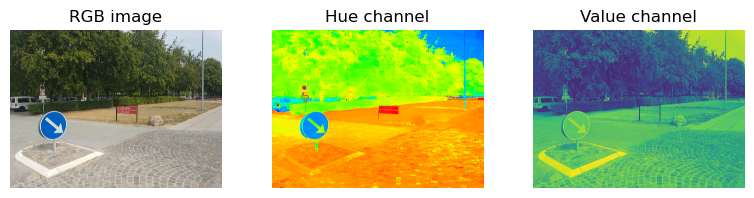

In [65]:
hsv_img = color.rgb2hsv(im_dtu_signs)
hue_img = hsv_img[:, :, 0]
value_img = hsv_img[:, :, 2]
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))
ax0.imshow(im_dtu_signs)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='hsv')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(value_img)
ax2.set_title("Value channel")
ax2.axis('off')

fig.tight_layout()
io.show()

In [66]:
print("Minimum pixel value (hue):", np.min(hue_img))
print("Maximum pixel value (hue):", np.max(hue_img))
print("Minimum pixel value (value):", np.min(value_img))
print("Maximum pixel value (value):", np.max(value_img))

Minimum pixel value (hue): 0.0
Maximum pixel value (hue): 0.9986111111111111
Minimum pixel value (value): 0.0
Maximum pixel value (value): 1.0


In [78]:
def detect_dtu_signs_hsv(img_in, sign_color='blue'):
    
    # Convert RGB to HSV
    img_hsv = color.rgb2hsv(img_in)
    
    h_comp = img_hsv[:, :, 0]
    s_comp = img_hsv[:, :, 1]
    v_comp = img_hsv[:, :, 2]

    if sign_color == 'blue':
        # Blue signs: R < 10, G: 85-105, B: 180-200
        # In HSV: Hue ~0.55-0.65 (blue), Saturation high, Value medium-high
        segm = (h_comp > 0.55) & (h_comp < 0.66) & \
                   (s_comp > 0.70) & \
                   (v_comp > 0.60) & (v_comp < 0.85)
    elif sign_color == 'red':
        # Red signs: R: 160-180, G < 70, B < 70
        # In HSV: Hue ~0.0 or ~1.0 (red wraps around), Saturation high, Value medium-high
        segm = ((h_comp < 0.10) | (h_comp > 0.90)) & \
                   (s_comp > 0.60) & \
                   (v_comp > 0.50) & (v_comp < 0.80)
    else:
        print("Color not supported. Please choose 'red' or 'blue'.")
        return None

    img_out = img_in.copy()
    img_out[segm] = [255, 255, 255]
    img_out[~segm] = [0, 0, 0]

    return img_out

In [79]:
im_dtu_signs_detected_blue_hsv = detect_dtu_signs_hsv(im_dtu_signs, sign_color='blue')
im_dtu_signs_detected_red_hsv = detect_dtu_signs_hsv(im_dtu_signs, sign_color='red')

/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/209517572.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs, ax=ax[0])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/209517572.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs_detected_blue_hsv, ax=ax[1])
/var/folders/ql/_84q8yn97vb9ftgh8fyj1jb40000gn/T/ipykernel_96535/209517572.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_dtu_signs_detected_red_hsv, ax=ax[2])
/Users/balpaula/miniforge3/envs/dtu02515/lib/python3.13/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range

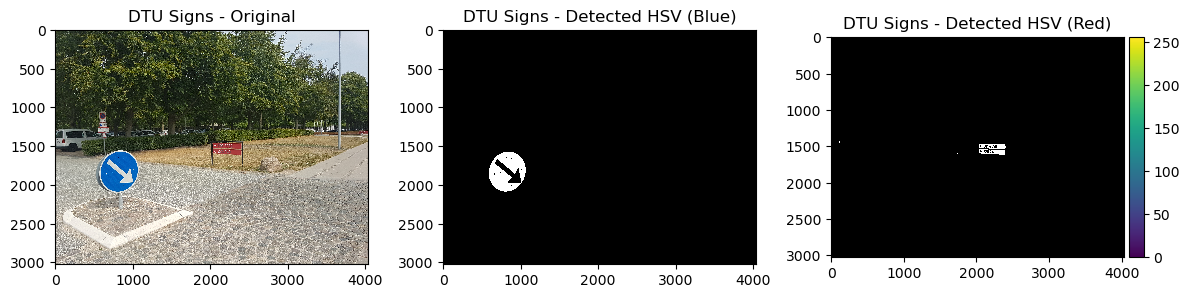

In [80]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
io.imshow(im_dtu_signs, ax=ax[0])
ax[0].set_title('DTU Signs - Original')
io.imshow(im_dtu_signs_detected_blue_hsv, ax=ax[1])
ax[1].set_title('DTU Signs - Detected HSV (Blue)')
io.imshow(im_dtu_signs_detected_red_hsv, ax=ax[2])
ax[2].set_title('DTU Signs - Detected HSV (Red)')
fig.show()


## Exercise 16
(Run the program from the exercise material and see if it shows the expected results?)

## Exercise 17

(Changes in process_gray_image function in Ex3-VideoPixelWiseOperations.py)

In [81]:
def process_gray_image(img):
    """
    Do a simple processing of an input gray scale image and return the processed image.
    # https://scikit-image.org/docs/stable/user_guide/data_types.html#image-processing-pipeline
    """
    img_float = img_as_float(img)
    
    # ANSWER TO EXERCISE 17
    
    # Method 1: Thresholding (converts to binary image)
    threshold_val = 0.5
    img_proc = (img_float > threshold_val).astype(float)
    
    # Method 2: Gamma mapping
    # gamma = 1.5
    # img_proc = img_float ** gamma
    
    # Method 3: Histogram stretching
    # min_val = img_float.min()
    # max_val = img_float.max()
    # img_proc = (img_float - min_val) / (max_val - min_val)
    
    # Method 4: Original inversion
    # img_proc = 1 - img_float
    
    return img_as_ubyte(img_proc)